#The historical daily closing price of many stocks is available for free online. Select a stock ticker of your choice, download its historical daily closing price for 1 year, create a .csv file out of those data and put it online (you will use a link to it in your program).

In [ ]:
#Я буду анализировать акции компании Apple за период с 05.05.2023 по 05.05.2024
!pip install gdown
import pandas as pd
import gdown

In [ ]:
url = 'https://drive.google.com/uc?id=1u5OERRQOm19yAYjPdDssd2Nt_DEjPNN0'
output = 'data.csv'
gdown.download(url, output, quiet=False)
df = pd.read_csv('data.csv')

Downloading...
From: https://drive.google.com/uc?id=1u5OERRQOm19yAYjPdDssd2Nt_DEjPNN0
To: /content/data.csv
100%|██████████| 18.9k/18.9k [00:00<00:00, 29.9MB/s]


## B. Plot the daily closing price of your chosen stock.

In [ ]:
closing_prices = df['Close']
print(closing_prices)

0      173.570007
1      173.500000
2      171.770004
3      173.559998
4      173.750000
          ...    
246    173.500000
247    170.330002
248    169.300003
249    173.029999
250    183.380005
Name: Close, Length: 251, dtype: float64


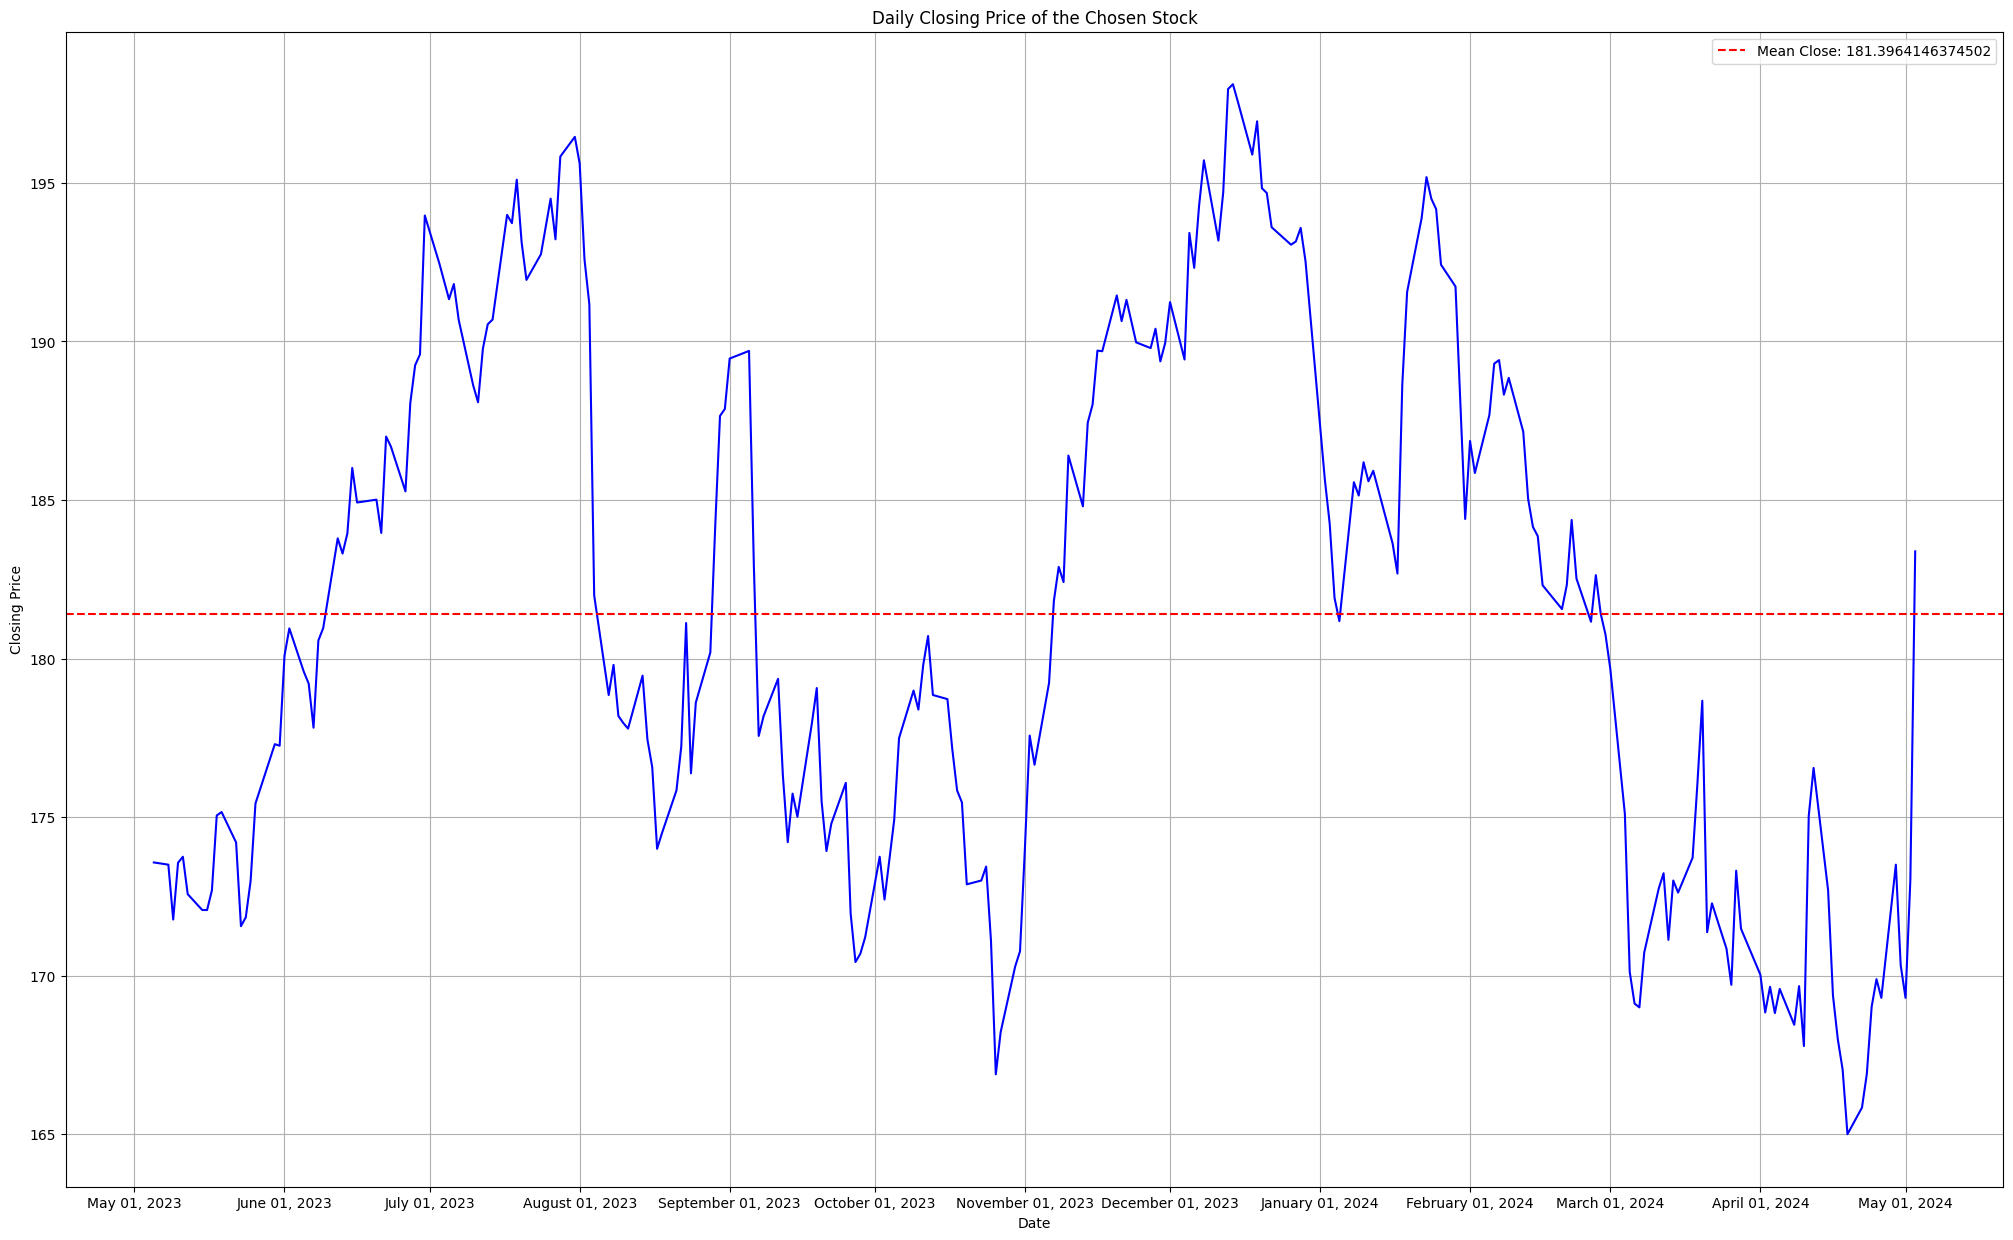

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter





# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

#ищем среднее по датасету значение
mean_close = df['Close'].mean()

plt.figure(figsize=(25, 15))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Daily Closing Price of the Chosen Stock')
plt.xlabel('Date')
plt.ylabel('Closing Price')


# Отображение названия месяца словом, номера дня месяца и года
plt.gca().xaxis.set_major_locator(MonthLocator())
plt.gca().xaxis.set_major_formatter(DateFormatter('%B %d, %Y'))

plt.axhline(mean_close, color='red', linestyle='--', label=f'Mean Close: {mean_close}')

plt.legend()

plt.grid(True)


After reviewing the plot, the following conclusions can be drawn:
1. It can be seen that the value of the deviation from the average value varies greatly.
2. The distances between peaks and troughs, then increase greatly, then decrease greatly (Irregular fluctuations)

Preliminary conclusion: the dataset is not stationary.

Let's test this theory.

# C. Determine if it is a random walk or not. If it is not a random walk, explain why.

I will use Augmented Dickey–Fuller (ADF) Test to check if the data is stationary.

The null hypothesis: there is a unit root present in a
time series.

The augmented Dickey-Fuller (ADF)
test helps us determine if a time
series is stationary by testing for the
presence of a unit root.
If a unit root is present, the time
series is not stationary.


In [ ]:
from statsmodels.tsa.stattools import adfuller


ADF_result = adfuller(df['Close'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')



ADF Statistic: -2.5341366162342798
p-value: 0.10738786894219465


This prints an ADF statistic of -2.5341366162342798 and a p-value of
0.10738786894219465. The ADF statistic is not a large negative number,
and with a p-value greater than 0.05, we can not
reject the null hypothesis.the series is not
stationary.

Conclusion: the dataset is not stationary.

#Data Transformation

ADF Statistic: -13.104001771482917
p-value: 1.6871155910996156e-24
We can reject the null hypothesis (the series is stationary)!


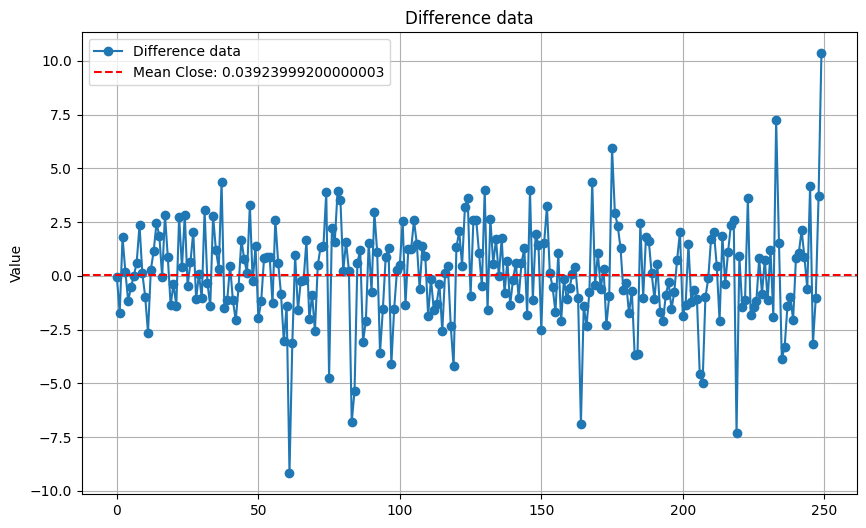

In [ ]:
import numpy as np
#Differencing

def diff_and_ADF(df):
    # Применение дифференцирования к столбцу 'Close'
    diff_random_walk = np.diff(df['Close'], n=1)
    #print(diff_random_walk )
    # Проверка стационарности после дифференцирования
    ADF_result = adfuller(diff_random_walk)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}')
    if ADF_result[1]<0.05:
      print('We can reject the null hypothesis (the series is stationary)!')
    mean_close = diff_random_walk.mean()

    plt.figure(figsize=(10, 6))
    plt.plot(diff_random_walk, marker='o', linestyle='-', label='Difference data')
    plt.axhline(mean_close, color='red', linestyle='--', label=f'Mean Close: {mean_close}')

    plt.title('Difference data')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()
    return diff_random_walk

diff_data=diff_and_ADF(df)


Great!
Now our data is stationary.
Because ADF Statistical: -13.104001771482917, and this is a large
negative numberand p_value is less than 0.05.

Therefore, we reject the null hypothesis, and we can
say that this process has no unit root and is thus
stationary

#Autocorrelation


●Autocorrelation of a time series is the idea that a
value in a time series at one given point in time may
have a correlation to the value at another point in
time. It is the similarity between observations as a
function of the time lag between them.

● The lag is the number of timesteps separating two
values.

● More formally, autocorrelation is the correlation of a
value with a delayed copy of itself as a function of
the delay.

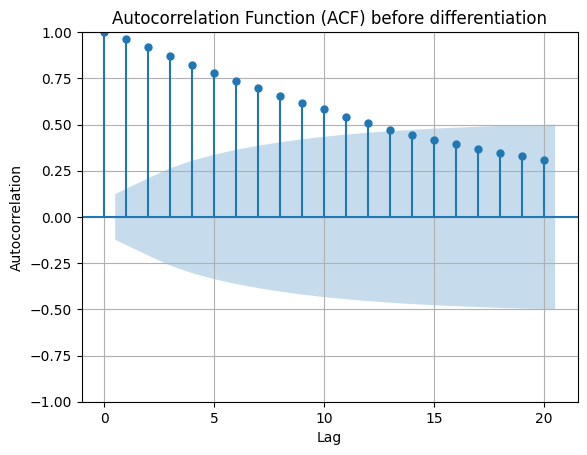

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Close'], lags=20)
plt.title('Autocorrelation Function (ACF) before differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

● The autocorrelation coefficients slowly decrease as
the lag increases, which is a clear indicator that our
random walk is not a stationary process.

● The shaded area represents a confidence interval.
If a point is within the shaded area, then it is not
significantly different from 0. Otherwise, the
autocorrelation coefficient is significant(as in the left half of this plot ).


#But the ACF graph of non-stationary data won't give us much information!

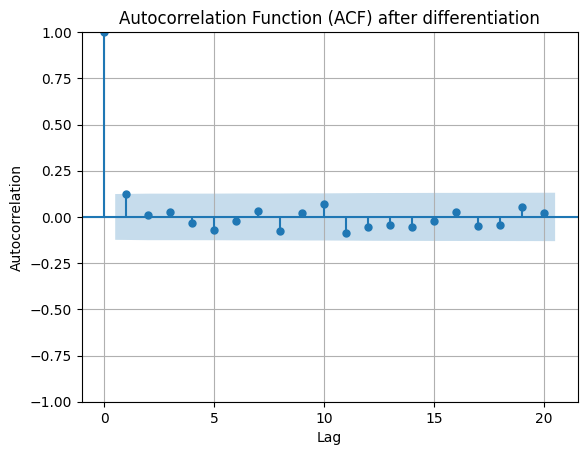

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(diff_data, lags=20)
plt.title('Autocorrelation Function (ACF) after differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()



● There are no significant autocorrelation coefficients
after lag 0.

● This means that the stationary process is completely
random and can therefore be described as white
noise. Each value is simply a random step away from
the previous one, with no relation between them.

##Conclusion: this is a random walk!

##D. Keep the last 5 days of data as a test set. The rest will be the train set.

In [ ]:
# Последние 5 дней данных будут тестовым набором
test_set = df['Close'][-5:]

# Остальные данные будут обучающим набором
train_set = df['Close'][:-5]


print("Train set size:", len(train_set))
print("Test set size:", len(test_set))


Train set size: 246
Test set size: 5


## E.Forecast the last 5 days using naive forecasting methods, and measure the MSE. Which method is the best?

In [ ]:

from sklearn.metrics import mean_squared_error


# 1 способ: заполнить всё средним значением
train_mean=np.mean(train_set)
train_mean_pred = np.full(len(test_set), train_mean)
print(mean_squared_error(test_set,train_mean_pred))

# 2 способ: взять и заполнить predict последним элементом test
train_last = train_set[245]
train_last_pred = np.full(len(test_set), train_last)
print(mean_squared_error(test_set,train_last_pred))

#3 способ: drift mode
deltaX=len(train_set)-1
deltaY=train_last
drift=deltaY/deltaX
values=np.arange(246,251,1)
#print(values)
test_drift=drift*values
print(mean_squared_error(test_set,test_drift))

# 4 способ: заполнить всё значением медианы
train_median = np.median(train_set)
train_median_pred = np.full(len(test_set), train_median)
print(mean_squared_error(test_set, train_median_pred))

# 5 способ: заролнить predict случайными значения из встречавшихся в test_set
np.random.seed(42)  # для воспроизводимости результатов
train_random_pred = np.random.choice(train_set, size=len(test_set))
print(mean_squared_error(test_set, train_random_pred))


# 6 способ: взять и заполнить predict первым элементом test
train_last = train_set[0]
train_first_pred = np.full(len(test_set), train_last)
print(mean_squared_error(test_set,train_first_pred))


83.31740511730317
46.172039844006036
26.111184279735955
74.59859872200425
145.48942350802412
25.052627388031627


From the above results, it can be concluded that the best methods used are drift mode and filling the predict with the first train value

#F. Plot your forecasts.

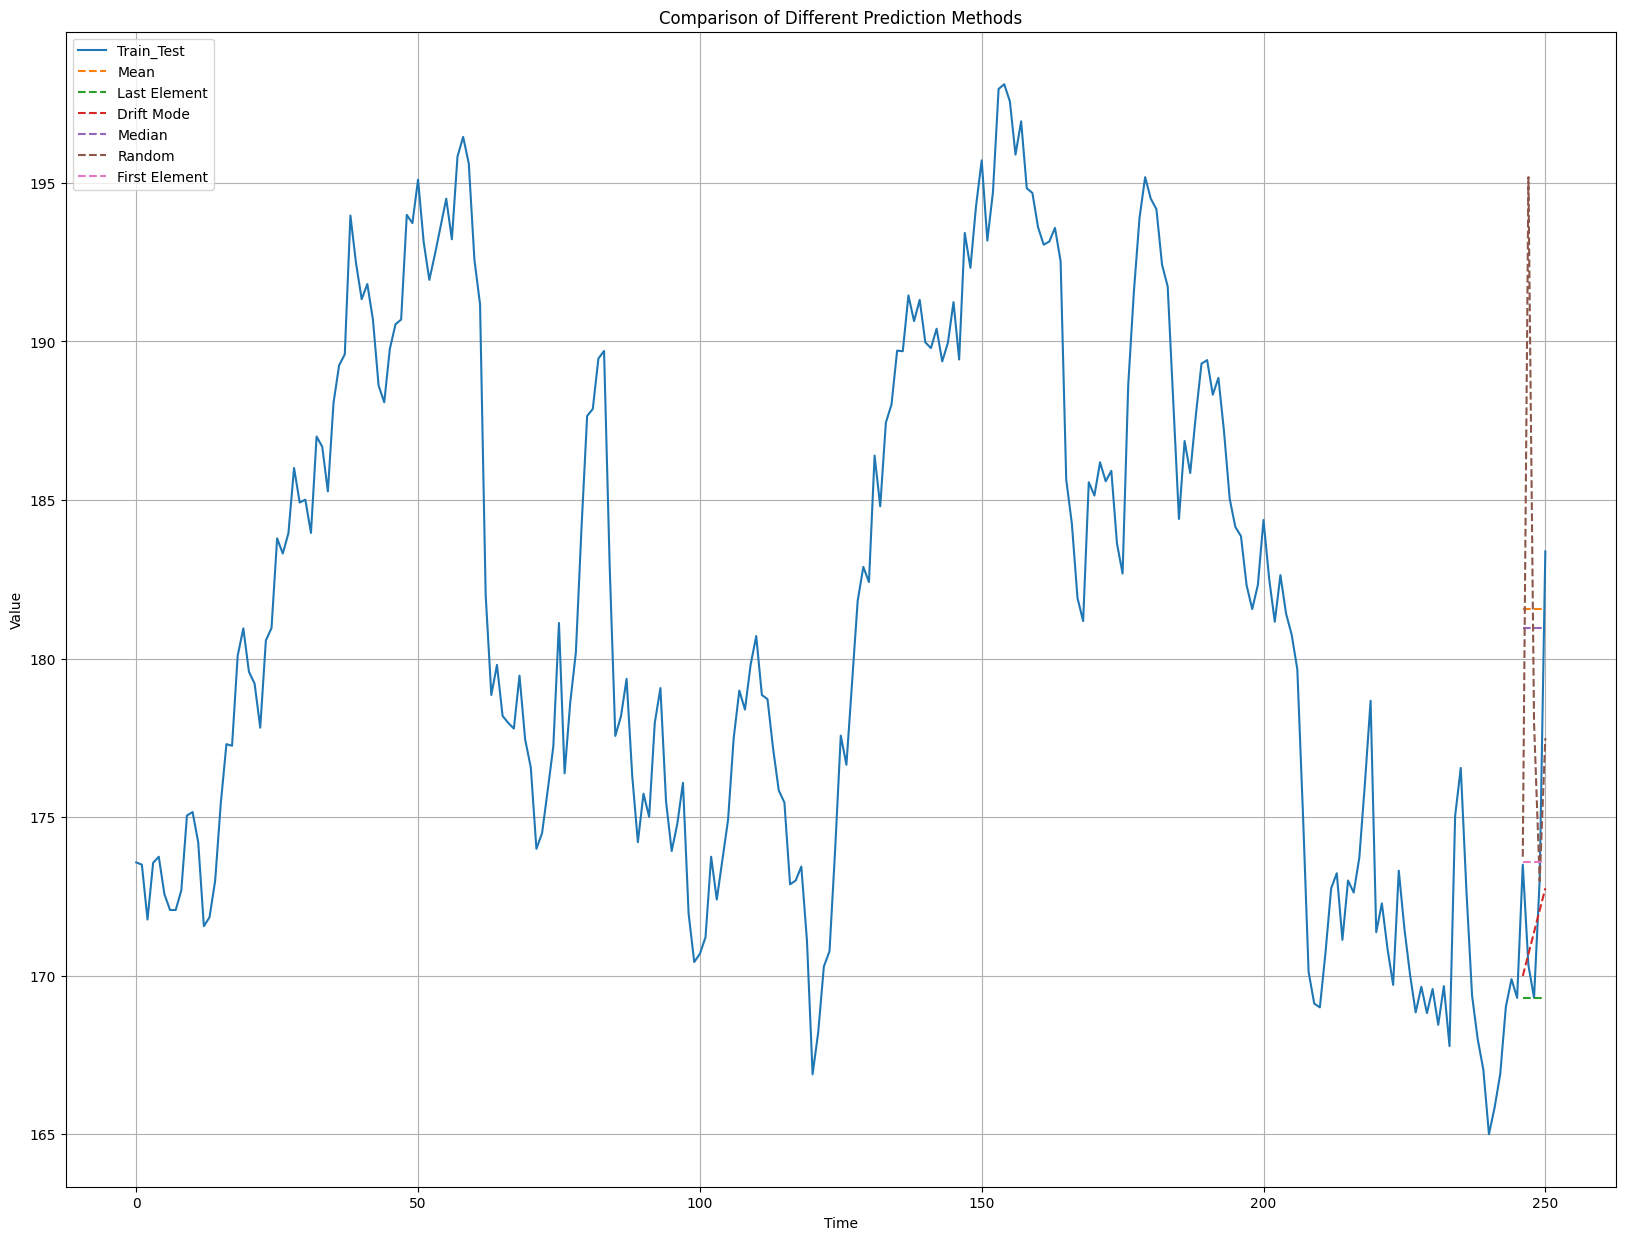

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 15))

plt.plot(np.arange(len(train_set) + len(test_set)), np.concatenate([train_set, test_set]), label='Train_Test')

plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_mean_pred, label='Mean', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_last_pred, label='Last Element', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), test_drift, label='Drift Mode', linestyle='--')

plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_median_pred, label='Median', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_random_pred, label='Random', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_first_pred, label='First Element', linestyle='--')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Comparison of Different Prediction Methods')
plt.legend()
plt.grid(True)


plt.show()


# G. Forecast the next timestep over the test set, and measure the MSE. Did it decrease?

In [ ]:
pred_shift_test=np.roll(test_set,1)
#print(pred_shift_test)
pred_shift_test[0]=train_set[245]
print(f'MSE for the rolled test data: {mean_squared_error(test_set,pred_shift_test)}')

MSE for the rolled test data: 29.957050884013217


##Conclusion: yes, the MSE obtained is not equal to the previously obtained result, however, this is not the smallest MSE value that was obtained.

#H. Plot your forecasts.

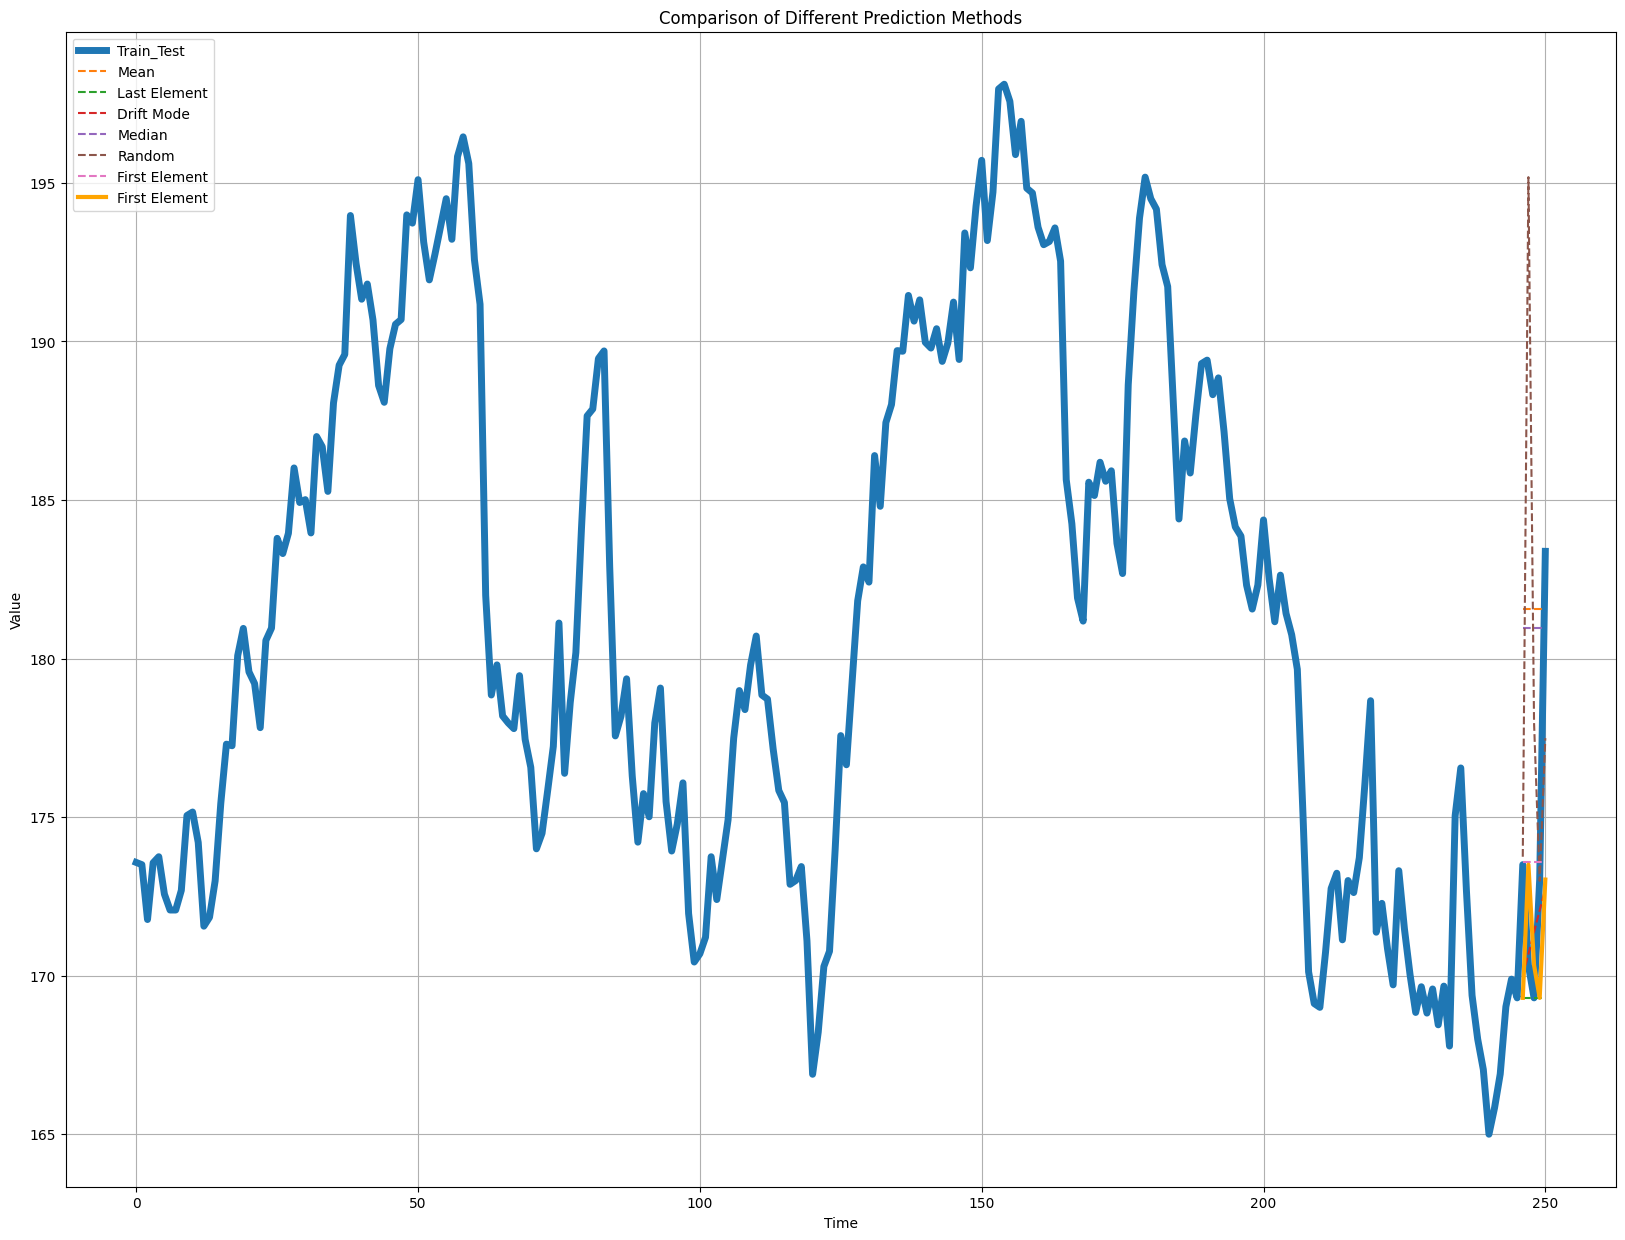

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 15))

plt.plot(np.arange(len(train_set) + len(test_set)), np.concatenate([train_set, test_set]), label='Train_Test',linewidth=5)

plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_mean_pred, label='Mean', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_last_pred, label='Last Element', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), test_drift, label='Drift Mode', linestyle='--')

plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_median_pred, label='Median', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_random_pred, label='Random', linestyle='--')
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), train_first_pred, label='First Element', linestyle='--')


#new
plt.plot(np.arange(len(train_set), len(train_set) + len(test_set)), pred_shift_test, label='First Element', linestyle='-', color='orange', linewidth=3)



plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Comparison of Different Prediction Methods')
plt.legend()
plt.grid(True)


plt.show()